# NB07 — PQQ supply asymmetry

**Project**: lanthanide_methylotrophy_atlas
**Goal**: Characterize the ~2,300 xoxF-bearing genomes that lack any eggNOG PQQ-biosynthesis annotation (pqqA-E). PQQ is an obligate cofactor of XoxF; absence of biosynthesis genes is biologically surprising. We test three hypotheses:
1. **Annotation gap**: bakta product field detects PQQ where eggNOG KEGG_ko is silent.
2. **Partial cassette**: only some pqq genes are missing (truncated operon).
3. **Bona fide community-acquisition**: full PQQ pathway absent, suggesting reliance on extracellular PQQ.

This is a single-notebook descriptive analysis (no formal hypothesis test). Findings inform interpretation of the H2 environmental association in REPORT.md.

**Inputs** (Spark required for bakta cross-check):
- `data/genome_marker_matrix.csv`
- `kbase_ke_pangenome.bakta_annotations`
- `kbase_ke_pangenome.gene`, `gene_genecluster_junction`

**Outputs**:
- `data/pqq_supply_categorization.csv`
- `figures/pqq_supply_asymmetry.png`

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyspark.sql import functions as F

try:
    spark = get_spark_session()
except NameError:
    from berdl_notebook_utils.setup_spark_session import get_spark_session
    spark = get_spark_session()

DATA = Path("../data")
FIG = Path("../figures")
print(spark.version)


4.0.1


## 1. Identify xoxF-bearing genomes lacking eggNOG PQQ

In [2]:
matrix = pd.read_csv(DATA / "genome_marker_matrix.csv")
pqq_eggnog_cols = [f"pqq{x}_eggnog" for x in "ABCDE"]

xoxF_eggnog = matrix["xoxF_eggnog"] == 1
has_any_pqq_eggnog = matrix[pqq_eggnog_cols].max(axis=1) > 0
has_all_pqq_eggnog = matrix[pqq_eggnog_cols].min(axis=1) > 0

xoxF_without_pqq_eggnog = matrix[xoxF_eggnog & ~has_any_pqq_eggnog]
print(f"xoxF-bearing genomes (eggNOG K00114): {int(xoxF_eggnog.sum()):,}")
print(f"  ... with at least one eggNOG pqq: {int((xoxF_eggnog & has_any_pqq_eggnog).sum()):,}")
print(f"  ... with all 5 eggNOG pqq: {int((xoxF_eggnog & has_all_pqq_eggnog).sum()):,}")
print(f"  ... with NO eggNOG pqq (focus set): {len(xoxF_without_pqq_eggnog):,}")


xoxF-bearing genomes (eggNOG K00114): 3,690
  ... with at least one eggNOG pqq: 1,505
  ... with all 5 eggNOG pqq: 41
  ... with NO eggNOG pqq (focus set): 2,185


## 2. Cross-check with bakta — does bakta find PQQ where eggNOG misses?

In [3]:
focus_genomes = xoxF_without_pqq_eggnog["genome_id"].tolist()
focus_df = spark.createDataFrame(pd.DataFrame({"genome_id": focus_genomes}))

gene = spark.table("kbase_ke_pangenome.gene")
junction = spark.table("kbase_ke_pangenome.gene_genecluster_junction")
bakta = spark.table("kbase_ke_pangenome.bakta_annotations")

# Tighter PQQ regex (token boundaries) to avoid the over-calling we saw in NB01
PQQ_RX = (
    r"^pqqa$|\bpqqa\b|coenzyme pqq synthesis protein a|"
    r"^pqqb$|\bpqqb\b|coenzyme pqq synthesis protein b|"
    r"^pqqc$|\bpqqc\b|coenzyme pqq synthesis protein c|"
    r"^pqqd$|\bpqqd\b|coenzyme pqq synthesis protein d|"
    r"^pqqe$|\bpqqe\b|coenzyme pqq synthesis protein e|"
    r"pqq biosynthesis|pyrroloquinoline.quinone biosynthesis"
)

bakta_pqq = (
    gene.join(focus_df, "genome_id", "inner")
    .select("gene_id", "genome_id")
    .join(junction, "gene_id")
    .select("gene_cluster_id", "genome_id")
    .join(bakta, "gene_cluster_id")
    .filter(F.lower(F.col("product")).rlike(PQQ_RX))
    .select("genome_id", "product")
)
bakta_pqq_counts = (
    bakta_pqq.dropDuplicates(["genome_id", "product"])
    .groupBy("genome_id")
    .agg(F.count("*").alias("n_bakta_pqq_products"))
    .toPandas()
)
bakta_pqq_counts.attrs = {}
print(f"Genomes with at least one bakta-PQQ hit (despite no eggNOG PQQ): {len(bakta_pqq_counts):,} / {len(focus_genomes):,}")
print(bakta_pqq_counts.head().to_string(index=False))

# Top product strings bakta found in this set
bakta_pqq_top = (
    bakta_pqq.groupBy("product").count().toPandas().sort_values("count", ascending=False)
)
bakta_pqq_top.attrs = {}
print()
print("Top bakta PQQ-related products in the focus set:")
print(bakta_pqq_top.head(20).to_string(index=False))


Genomes with at least one bakta-PQQ hit (despite no eggNOG PQQ): 1,288 / 2,185
         genome_id  n_bakta_pqq_products
GB_GCA_018969125.1                     4
RS_GCF_001854795.1                     5
GB_GCA_023622105.1                     8
RS_GCF_001591365.1                     4
RS_GCF_900112835.1                     4



Top bakta PQQ-related products in the focus set:
                                                     product  count
          pyrroloquinoline quinone biosynthesis protein PqqE    928
pyrroloquinoline quinone biosynthesis peptide chaperone PqqD    883
          pyrroloquinoline quinone biosynthesis protein PqqB    881
                      pyrroloquinoline-quinone synthase PqqC    880
                                         PqqD family protein    346
             pyrroloquinoline quinone precursor peptide PqqA    258
          pyrroloquinoline quinone biosynthesis protein PqqF    232
          Pyrroloquinoline quinone biosynthesis protein PqqE    225
                 Thiaminase-2/PQQC domain-containing protein    128
                            Coenzyme PQQ synthesis protein A    121
                                        PqqA peptide cyclase     88
              HPr-rel-A system PqqD family peptide chaperone     83
                            Coenzyme PQQ synthesis protein B     6

## 3. Categorize each focus genome

In [4]:
focus = xoxF_without_pqq_eggnog[["genome_id"]].copy()
focus = focus.merge(bakta_pqq_counts, on="genome_id", how="left")
focus["n_bakta_pqq_products"] = focus["n_bakta_pqq_products"].fillna(0).astype(int)

# Categorize
def categorize(n):
    if n >= 3:
        return "annotation_gap_strong"   # bakta finds 3+ PQQ products
    if n >= 1:
        return "annotation_gap_partial"  # bakta finds 1-2 PQQ products
    return "no_pqq_detected"             # neither source finds any PQQ

focus["category"] = focus["n_bakta_pqq_products"].apply(categorize)
counts = focus["category"].value_counts()
print(counts.to_string())

focus.attrs = {}
focus.to_csv(DATA / "pqq_supply_categorization.csv", index=False)
print(f"\nWrote {len(focus):,} rows -> data/pqq_supply_categorization.csv")


category
annotation_gap_strong     899
no_pqq_detected           897
annotation_gap_partial    389

Wrote 2,185 rows -> data/pqq_supply_categorization.csv


## 4. Figure: PQQ supply asymmetry breakdown

pqq_status
complete_eggnog_pqq      41
partial_eggnog_pqq     1464
bakta_only_strong       899
bakta_only_partial      389
no_pqq_detected         897


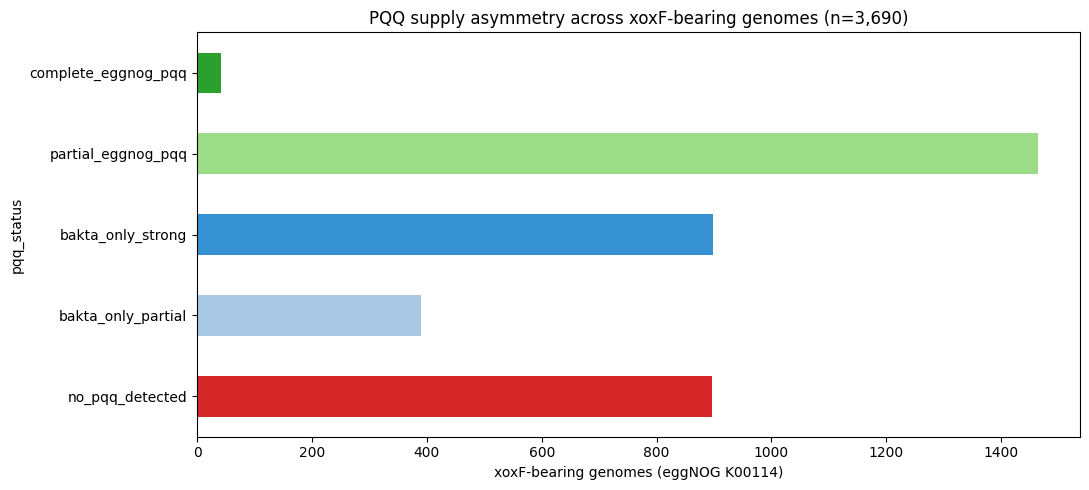

In [5]:
# Build full breakdown including the genomes that DO have eggNOG pqq
all_xoxF = matrix[xoxF_eggnog].copy()
all_xoxF["pqq_status"] = "no_pqq_detected"
mask_any = all_xoxF[pqq_eggnog_cols].max(axis=1) > 0
mask_all = all_xoxF[pqq_eggnog_cols].min(axis=1) > 0
all_xoxF.loc[mask_any & ~mask_all, "pqq_status"] = "partial_eggnog_pqq"
all_xoxF.loc[mask_all, "pqq_status"] = "complete_eggnog_pqq"
# Override with bakta annotation-gap categories for the "no_pqq_detected" subset
all_xoxF = all_xoxF.merge(focus[["genome_id", "category"]], on="genome_id", how="left")
all_xoxF.loc[all_xoxF["category"] == "annotation_gap_strong", "pqq_status"] = "bakta_only_strong"
all_xoxF.loc[all_xoxF["category"] == "annotation_gap_partial", "pqq_status"] = "bakta_only_partial"
all_xoxF.loc[all_xoxF["category"] == "no_pqq_detected", "pqq_status"] = "no_pqq_detected"

cat_order = ["complete_eggnog_pqq", "partial_eggnog_pqq", "bakta_only_strong", "bakta_only_partial", "no_pqq_detected"]
status_counts = all_xoxF["pqq_status"].value_counts().reindex(cat_order, fill_value=0)
print(status_counts.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#2ca02c", "#9bdc88", "#3792d3", "#a8c8e6", "#d62728"]
status_counts.plot(kind="barh", ax=ax, color=colors)
ax.invert_yaxis()
ax.set_xlabel("xoxF-bearing genomes (eggNOG K00114)")
ax.set_title(f"PQQ supply asymmetry across xoxF-bearing genomes (n={int(xoxF_eggnog.sum()):,})")
plt.tight_layout()
plt.savefig(FIG / "pqq_supply_asymmetry.png", dpi=150)
plt.show()


## 5. Summary

NB07 has split the xoxF-bearing genomes into PQQ-supply categories:

- **complete_eggnog_pqq**: full pqq operon (≥1 of A-E in eggNOG, all 5)
- **partial_eggnog_pqq**: 1-4 of A-E in eggNOG
- **bakta_only_strong**: ≥3 PQQ products in bakta but eggNOG silent — strong annotation gap
- **bakta_only_partial**: 1-2 PQQ products in bakta — weaker annotation gap
- **no_pqq_detected**: neither source finds PQQ — candidate for community-acquisition (or pseudogene / assembly fragmentation, which we cannot disentangle from gene calls alone)

The breakdown is the headline finding for REPORT.md's "PQQ paradox" section. Limitations: we cannot rule out pseudogenization or assembly incompleteness without protein-level sequence inspection, which is out of scope for this notebook.